In [1]:
import os
import cv2
import random
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import balanced_accuracy_score, confusion_matrix

- **Detecção de rosto e olhos**:
  - **classificadores Haar Cascade**: técnica clássica baseada em características Haar e classificadores fracos combinados com AdaBoost.
  - Dois classificadores pré-treinados do OpenCV são utilizados:
    - `haarcascade_frontalface_default.xml` para detecção de rostos.
    - `haarcascade_eye.xml` para detecção de olhos dentro da região do rosto.

- **Estimativa da rotação**:
  - Testa todas as quatro rotações possíveis (0°, 90°, 180°, 270°) para cada imagem.
  - Para cada rotação:
    - Detecta rostos e, dentro deles, os olhos.
    - Se forem detectados dois ou mais olhos, considera essa a rotação correta.
    - Caso contrário, seleciona a rotação com o maior número de olhos detectados.

- **Avaliação**:
  - Compara a rotação estimada com a rotação real aplicada.
  - Calcula a **Acurácia Balanceada** e **matriz de confusão**.

- **Visualização**:
  - Mostra amostras de imagens com:
    - Posições dos olhos detectadas (retângulos verdes).
    - Rótulos indicando a rotação verdadeira e a rotação estimada.


In [2]:
face_cascade = cv2.CascadeClassifier("../models/haarcascade_frontalface_default.xml")
eye_cascade = cv2.CascadeClassifier("../models/haarcascade_eye.xml")

def rotate_image(image, angle):
    """
    Rotates an image by the given angle.

    Args:
        image (np.ndarray): Input image.
        angle (int): Rotation angle (0, 90, 180, 270).

    Returns:
        np.ndarray: Rotated image.
    """
    if angle == 0:
        return image
    elif angle == 90:
        return cv2.rotate(image, cv2.ROTATE_90_CLOCKWISE)
    elif angle == 180:
        return cv2.rotate(image, cv2.ROTATE_180)
    elif angle == 270:
        return cv2.rotate(image, cv2.ROTATE_90_COUNTERCLOCKWISE)


def estimate_rotation_angle(image):
    """
    Estimates the face rotation angle in the input image.

    Args:
        image (np.ndarray): Input image in BGR format.

    Returns:
        tuple: (angle, rotated_image, features, confident)
            angle (int or None): Estimated angle.
            rotated_image (np.ndarray or None): Best rotated image.
            features (dict): Detected eye positions.
            confident (bool): True if at least two eyes detected.
    """
    best_angle = None
    max_eyes = 0
    best_image = None
    best_features = {}

    for angle in [0, 90, 180, 270]:
        rotated = rotate_image(image, angle)
        gray = cv2.cvtColor(rotated, cv2.COLOR_BGR2GRAY)
        faces = face_cascade.detectMultiScale(gray, 1.3, 5)

        for (x, y, w, h) in faces:
            roi_gray = gray[y:y + h, x:x + w]
            eyes = eye_cascade.detectMultiScale(roi_gray)
            features = {
                "eyes": [(x + ex, y + ey, ew, eh) for (ex, ey, ew, eh) in eyes]
            }

            if len(eyes) >= 2:
                return angle, rotated, features, True

            if len(eyes) > max_eyes:
                max_eyes = len(eyes)
                best_angle = angle
                best_image = rotated
                best_features = features

    return best_angle, best_image, best_features, False


def load_images(base_path, seed=96):
    """
    Loads image paths from the specified folder.

    Args:
        base_path (str): Root folder path.
        seed (int): Seed for shuffling.

    Returns:
        list: Shuffled list of image file paths.
    """
    image_paths = []
    for root, _, files in os.walk(base_path):
        for f in files:
            if f.lower().endswith(('.png', '.jpg', '.jpeg', '.pgm')):
                image_paths.append(os.path.join(root, f))
    random.seed(seed)
    random.shuffle(image_paths)
    return image_paths


def process_images(base_path, max_valid_images=20, seed=96, limit_images=True):
    """
    Processes images by applying random rotations and estimating orientation.

    Args:
        base_path (str): Dataset folder.
        max_valid_images (int): Maximum number of processed images.
        seed (int): Seed for reproducibility.
        limit_images (bool): Whether to limit the number of images.

    Returns:
        list: List of tuples (path, true_rotation, estimated_rotation, annotated_image)
    """
    image_paths = load_images(base_path, seed=seed)
    results = []
    random.seed(seed)

    for image_path in image_paths:
        if limit_images and len(results) >= max_valid_images:
            break

        image = cv2.imread(image_path)
        if image is None:
            continue

        true_rotation = random.choice([0, 90, 180, 270])
        rotated = rotate_image(image, true_rotation)

        display_rotation = {
            0: 0,
            90: 270,
            180: 180,
            270: 90
        }[true_rotation]

        estimated_angle, annotated, features, _ = estimate_rotation_angle(rotated)

        if annotated is not None and estimated_angle is not None:
            for (ex, ey, ew, eh) in features.get("eyes", []):
                cv2.rectangle(annotated, (ex, ey), (ex + ew, ey + eh), (0, 255, 0), 2)

            results.append((image_path, display_rotation, estimated_angle, annotated))

    return results


def compute_metrics(results):
    """
    Computes and prints the balanced accuracy and confusion matrix.

    Args:
        results (list): List of processed image results.
    """
    true_labels = [true for _, true, _, _ in results]
    pred_labels = [pred for _, _, pred, _ in results]

    acc = balanced_accuracy_score(true_labels, pred_labels)
    print(f"Balanced Accuracy: {acc:.4f}")

    cm = confusion_matrix(true_labels, pred_labels, labels=[0, 90, 180, 270])
    plt.figure(figsize=(5, 4))
    plt.imshow(cm, cmap="Blues", interpolation="nearest")
    plt.title("Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    classes = ['0°', '90°', '180°', '270°']
    plt.xticks(np.arange(4), classes)
    plt.yticks(np.arange(4), classes)

    for i in range(4):
        for j in range(4):
            plt.text(j, i, cm[i, j], ha="center", va="center", color="black")

    plt.tight_layout()
    plt.show()


def plot_results(results, max_valid_images=20):
    """
    Plots annotated images with true and predicted rotations.

    Args:
        results (list): List of processed image results.
        max_valid_images (int): Number of images to plot.
    """
    n_cols = 5
    n_rows = (min(len(results), max_valid_images) + n_cols - 1) // n_cols
    plt.figure(figsize=(4 * n_cols, 4 * n_rows))

    for idx, (image_path, true_rot, est_rot, annotated_image) in enumerate(results[:max_valid_images], 1):
        rgb_image = cv2.cvtColor(annotated_image, cv2.COLOR_BGR2RGB)
        filename = os.path.basename(image_path)
        plt.subplot(n_rows, n_cols, idx)
        plt.imshow(rgb_image)
        plt.title(f"{filename}\nTrue: {true_rot}°, Est: {est_rot}°")
        plt.axis('off')

    plt.tight_layout()
    plt.show()

Balanced Accuracy: 1.0000


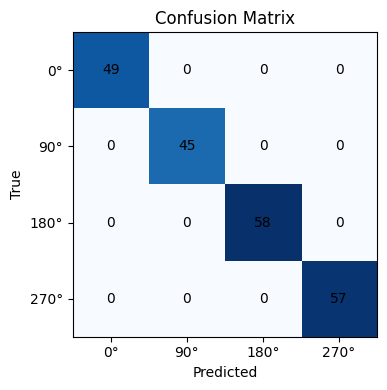

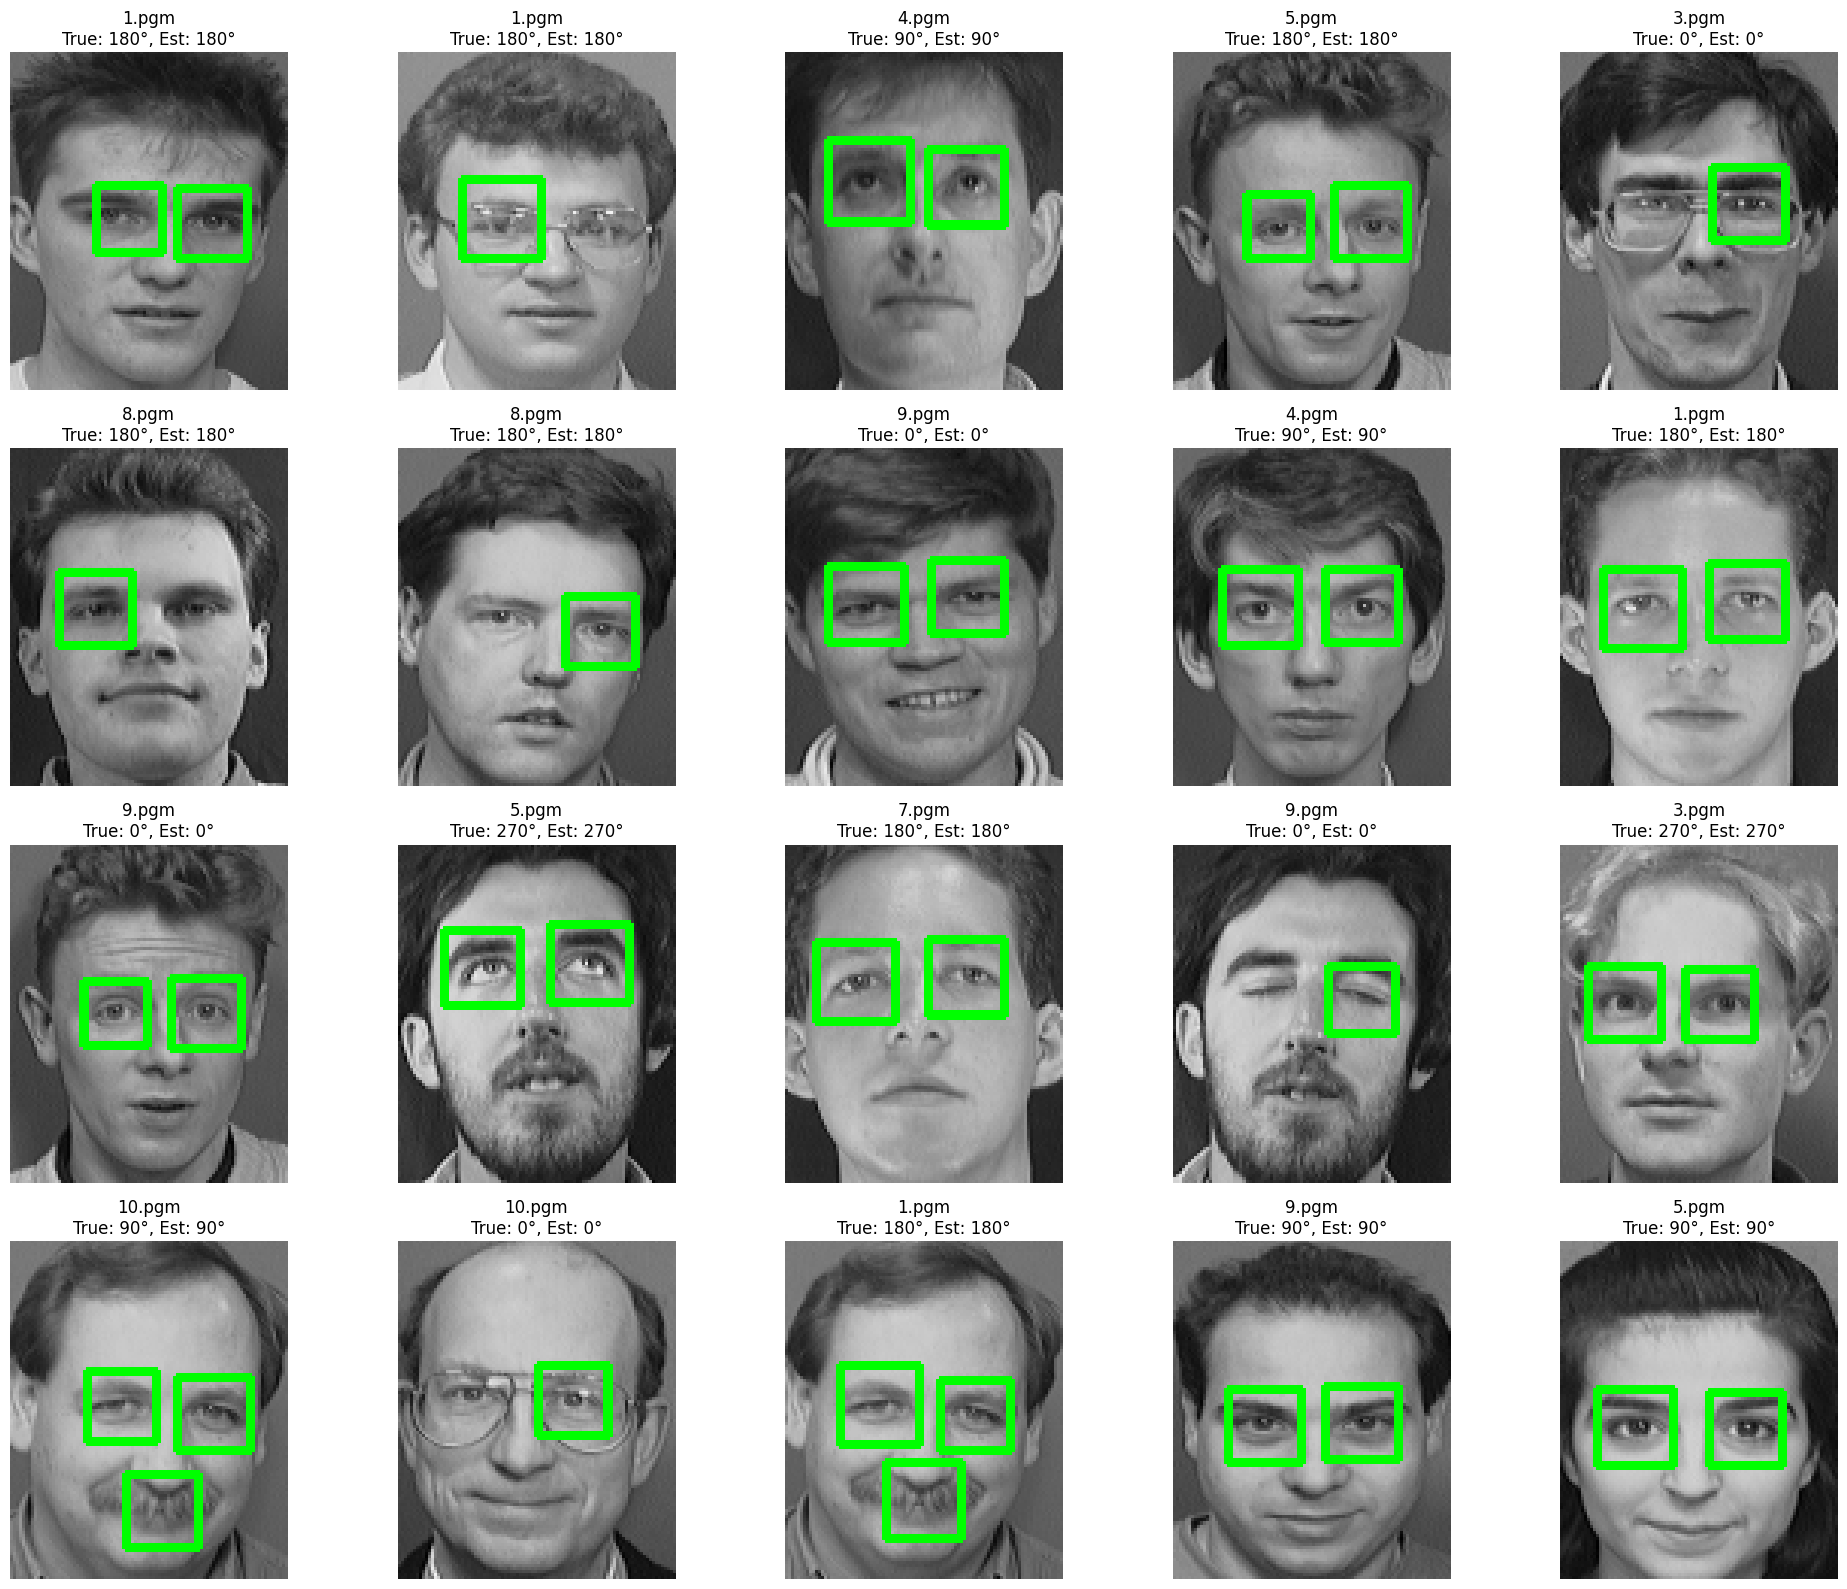

In [3]:
base_path = "../data/"
max_valid_images = 20

results_all = process_images(base_path=base_path, max_valid_images=max_valid_images, limit_images=False)
compute_metrics(results_all)
plot_results(results_all, max_valid_images=max_valid_images)